In [6]:
# ============================================================
# LABELING SUMMARY
# ============================================================
# - Loaded the aggregated ML table.
# - Used delivered_date_min and estimated_delivery_date_min as
#   the source dates for the delay label.
# - Converted both columns to datetime.
# - Calculated delay_days as the difference between actual and
#   estimated delivery dates in days.
# - Created the binary delayed label: 1 = delayed, 0 = not delayed.
# - Orders with missing delivery information remain unlabeled (NA).
# - Validated delay statistics, class distribution, delay periods,
#   and label consistency.
# - Saved the labeled dataset for the next modeling stage.

In [7]:
import pandas as pd

ml_table = pd.read_csv("../data/ML_Table_1.csv")

print("Shape:", ml_table.shape)
display(ml_table.head())

Shape: (99441, 80)


,order_id,customer_id,order_status,customer_zip_code_prefix,customer_state,customer_lat,customer_lng,purchase_time_min,purchase_time_max,purchase_time_median,...,payment_type_debit_card,payment_type_not_defined,payment_type_voucher,review_count,review_creation_min,review_creation_max,review_creation_median,review_answer_min,review_answer_max,review_answer_median
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,3149,SP,-23.576170,-46.587276,2017-10-02 10:56:33,2017-10-02 10:56:33,2017-10-02 10:56:33,...,0.0,0.0,1.0,1.0,2017-10-11,2017-10-11,2017-10-11 00:00:00,2017-10-12 03:43:48,2017-10-12 03:43:48,2017-10-12 03:43:48.000
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,47813,BA,-12.126651,-45.008162,2018-07-24 20:41:37,2018-07-24 20:41:37,2018-07-24 20:41:37,...,0.0,0.0,0.0,1.0,2018-08-08,2018-08-08,2018-08-08 00:00:00,2018-08-08 18:37:50,2018-08-08 18:37:50,2018-08-08 18:37:50.000
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,75265,GO,-16.744472,-48.514624,2018-08-08 08:38:49,2018-08-08 08:38:49,2018-08-08 08:38:49,...,0.0,0.0,0.0,1.0,2018-08-18,2018-08-18,2018-08-18 00:00:00,2018-08-22 19:07:58,2018-08-22 19:07:58,2018-08-22 19:07:58.000
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,59296,RN,-5.774611,-35.273916,2017-11-18 19:28:06,2017-11-18 19:28:06,2017-11-18 19:28:06,...,0.0,0.0,0.0,1.0,2017-12-03,2017-12-03,2017-12-03 00:00:00,2017-12-05 19:21:58,2017-12-05 19:21:58,2017-12-05 19:21:58.000
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,9195,SP,-23.675316,-46.515116,2018-02-13 21:18:39,2018-02-13 21:18:39,2018-02-13 21:18:39,...,0.0,0.0,0.0,1.0,2018-02-17,2018-02-17,2018-02-17 00:00:00,2018-02-18 13:02:51,2018-02-18 13:02:51,2018-02-18 13:02:51.000


In [8]:
import pandas as pd

ml_table = pd.read_csv("../data/ML_Table_1.csv")

print("Shape:", ml_table.shape)

label_cols = [
    "delivered_date_min",
    "estimated_delivery_date_min"
]

print("\nColumns:")
print(ml_table[label_cols].dtypes)

print("\nMissing values:")
print(ml_table[label_cols].isna().sum())

print("\nFirst 10 rows:")
display(ml_table[label_cols].head(10))

Shape: (99441, 80)

Columns:
delivered_date_min             str
estimated_delivery_date_min    str
dtype: object

Missing values:
delivered_date_min             2965
estimated_delivery_date_min       0
dtype: int64

First 10 rows:


,delivered_date_min,estimated_delivery_date_min
0,2017-10-10 21:25:13,2017-10-18
1,2018-08-07 15:27:45,2018-08-13
2,2018-08-17 18:06:29,2018-09-04
3,2017-12-02 00:28:42,2017-12-15
4,2018-02-16 18:17:02,2018-02-26
5,2017-07-26 10:57:55,2017-08-01
6,NaN,2017-05-09
7,2017-05-26 12:55:51,2017-06-07
8,2017-02-02 14:08:10,2017-03-06
9,2017-08-16 17:14:30,2017-08-23


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LABELING — LOAD ML TABLE
# ============================================================

ml_table = pd.read_csv("../data/ML_Table_1.csv")

print("=" * 100)
print("ML TABLE")
print("=" * 100)
print(f"Shape: {ml_table.shape}")

# ============================================================
# 1. LABEL SOURCE COLUMNS
# ============================================================

label_cols = [
    "delivered_date_min",
    "estimated_delivery_date_min"
]

print("\n" + "=" * 100)
print("LABEL SOURCE COLUMNS")
print("=" * 100)

print(ml_table[label_cols].dtypes)

print("\nMissing values:")
print(ml_table[label_cols].isna().sum())

display(
    ml_table[
        ["order_id", "order_status"] + label_cols
    ].head(10)
)

# ============================================================
# 2. DATETIME CONVERSION
# ============================================================

for col in label_cols:
    ml_table[col] = pd.to_datetime(
        ml_table[col],
        errors="coerce"
    )

# ============================================================
# 3. CREATE DELAY_DAYS
# ============================================================

ml_table["delay_days"] = (
    ml_table["delivered_date_min"]
    - ml_table["estimated_delivery_date_min"]
).dt.total_seconds() / (24 * 60 * 60)

# ============================================================
# 4. CREATE BINARY LABEL
# ============================================================

ml_table["delayed"] = pd.NA

valid = ml_table["delay_days"].notna()

ml_table.loc[valid, "delayed"] = (
    ml_table.loc[valid, "delay_days"] > 0
).astype(int)

ml_table["delayed"] = ml_table["delayed"].astype("Int64")

# ============================================================
# 5. LABEL PREVIEW
# ============================================================

print("\n" + "=" * 100)
print("LABEL PREVIEW")
print("=" * 100)

display(
    ml_table[
        [
            "order_id",
            "order_status",
            "delivered_date_min",
            "estimated_delivery_date_min",
            "delay_days",
            "delayed"
        ]
    ].head(20)
)

# ============================================================
# 6. DELAY_DAYS VALIDATION
# ============================================================

print("\n" + "=" * 100)
print("DELAY_DAYS VALIDATION")
print("=" * 100)

print(f"Missing: {ml_table['delay_days'].isna().sum():,}")
print(f"Unique:  {ml_table['delay_days'].nunique():,}")

print("\nStatistics:")
display(
    ml_table["delay_days"]
    .describe()
    .round(3)
)

# ============================================================
# 7. LABEL DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("DELAYED LABEL DISTRIBUTION")
print("=" * 100)

label_counts = (
    ml_table["delayed"]
    .value_counts(dropna=False)
    .sort_index()
)

label_summary = pd.DataFrame({
    "count": label_counts,
    "percentage": (
        label_counts / len(ml_table) * 100
    ).round(2)
})

display(label_summary)

# ============================================================
# 8. CLASS BALANCE
# ============================================================

print("\n" + "=" * 100)
print("CLASS BALANCE")
print("=" * 100)

counts = ml_table["delayed"].value_counts()

if 0 in counts and 1 in counts:
    majority = counts.max()
    minority = counts.min()
    imbalance_ratio = majority / minority

    print(f"On Time (0): {counts[0]:,}")
    print(f"Late (1):    {counts[1]:,}")
    print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

print(f"Unknown:     {ml_table['delayed'].isna().sum():,}")

# ============================================================
# 9. DELAY CATEGORIES
# ============================================================

print("\n" + "=" * 100)
print("DELAY CATEGORIES")
print("=" * 100)

delay_categories = pd.Series({
    "Early (< 0 days)": (
        ml_table["delay_days"] < 0
    ).sum(),

    "On time (= 0 days)": (
        ml_table["delay_days"] == 0
    ).sum(),

    "Delayed (> 0 days)": (
        ml_table["delay_days"] > 0
    ).sum(),

    "Unknown (NaN)": (
        ml_table["delay_days"].isna()
    ).sum()
})

display(
    pd.DataFrame({
        "count": delay_categories,
        "percentage": (
            delay_categories / len(ml_table) * 100
        ).round(2)
    })
)

# ============================================================
# 10. DELAY PERIODS — LATE ORDERS ONLY
# ============================================================

late = ml_table[ml_table["delayed"] == 1].copy()
bins = [0, 7, 14, 21, 30, 60, 90, 180, 365,float("inf")]
labels = [
    "≤ 1 week",
    "1–2 weeks",
    "2–3 weeks",
    "3–4 weeks",
    "1–2 months",
    "2–3 months",
    "3–6 months",
    "6–12 months",
    "> 1 year"
]

late["delay_period"] = pd.cut(late["delay_days"],bins=bins,labels=labels,right=True)
print("\n" + "=" * 100)
print("DELAY PERIODS")
print("=" * 100)
print(f"Late orders: {len(late):,}")
display(late["delay_period"].value_counts().sort_index())
# ============================================================
# 11. FINAL LABELING CHECK
# ============================================================

print("\n" + "=" * 100)
print("FINAL LABELING CHECK")
print("=" * 100)

expected_delayed = pd.Series(
    pd.NA,
    index=ml_table.index,
    dtype="Int64"
)

expected_delayed.loc[valid] = (
    ml_table.loc[valid, "delay_days"] > 0
).astype(int)

inconsistency = (
    ml_table["delayed"] != expected_delayed
).fillna(False).sum()

print(f"Inconsistent labels: {inconsistency:,}")

assert inconsistency == 0

# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("FINAL LABELING SUMMARY")
print("=" * 100)

print(f"Total orders:        {len(ml_table):,}")
print(f"Known delay:         {valid.sum():,}")
print(f"Unknown delay:       {(~valid).sum():,}")
print(f"On Time (0):         {(ml_table['delayed'] == 0).sum():,}")
print(f"Late (1):            {(ml_table['delayed'] == 1).sum():,}")
print(f"Early (<0 days):     {(ml_table['delay_days'] < 0).sum():,}")

ML TABLE
Shape: (99441, 80)

LABEL SOURCE COLUMNS
delivered_date_min             str
estimated_delivery_date_min    str
dtype: object

Missing values:
delivered_date_min             2965
estimated_delivery_date_min       0
dtype: int64


,order_id,order_status,delivered_date_min,estimated_delivery_date_min
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-16 18:17:02,2018-02-26
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,NaN,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,delivered,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,delivered,2017-02-02 14:08:10,2017-03-06
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,2017-08-16 17:14:30,2017-08-23



LABEL PREVIEW


,order_id,order_status,delivered_date_min,estimated_delivery_date_min,delay_days,delayed
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-10 21:25:13,2017-10-18,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-08-07 15:27:45,2018-08-13,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-17 18:06:29,2018-09-04,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-12-02 00:28:42,2017-12-15,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-16 18:17:02,2018-02-26,-9.238171,0
5,a4591c265e18cb1dcee52889e2d8acc3,delivered,2017-07-26 10:57:55,2017-08-01,-5.543113,0
6,136cce7faa42fdb2cefd53fdc79a6098,invoiced,NaT,2017-05-09,NaN,<NA>
7,6514b8ad8028c9f2cc2374ded245783f,delivered,2017-05-26 12:55:51,2017-06-07,-11.461215,0
8,76c6e866289321a7c93b82b54852dc33,delivered,2017-02-02 14:08:10,2017-03-06,-31.410995,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,delivered,2017-08-16 17:14:30,2017-08-23,-6.281597,0



DELAY_DAYS VALIDATION
Missing: 2,965
Unique:  91,915

Statistics:


...


CLASS BALANCE
On Time (0): 88,649
Late (1):    7,827
Imbalance ratio: 11.33:1
Unknown:     2,965

DELAY CATEGORIES


,count,percentage
Early (< 0 days),88649,89.15
On time (= 0 days),0,0.00
Delayed (> 0 days),7827,7.87
Unknown (NaN),2965,2.98



DELAY PERIODS
Late orders: 7,827


delay_period
≤ 1 week       4481
1–2 weeks      1791
2–3 weeks       760
3–4 weeks       435
1–2 months      276
2–3 months       37
3–6 months       45
6–12 months       2
> 1 year          0
Name: count, dtype: int64


FINAL LABELING CHECK
Inconsistent labels: 0

FINAL LABELING SUMMARY
Total orders:        99,441
Known delay:         96,476
Unknown delay:       2,965
On Time (0):         88,649
Late (1):            7,827
Early (<0 days):     88,649


In [10]:
! pip install matplotlib

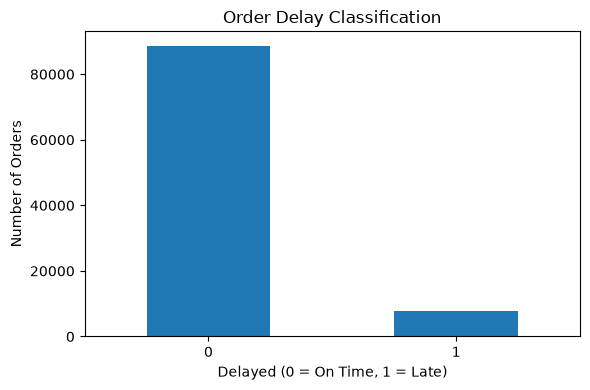

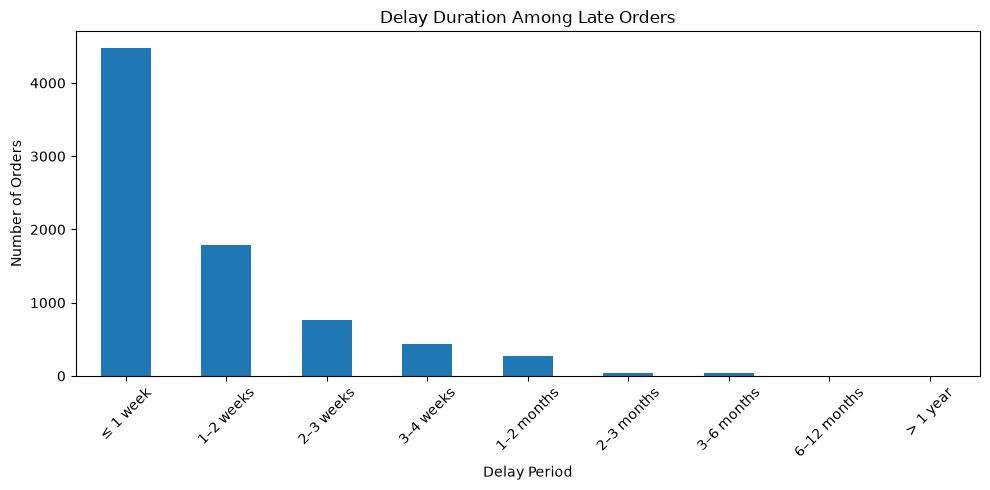

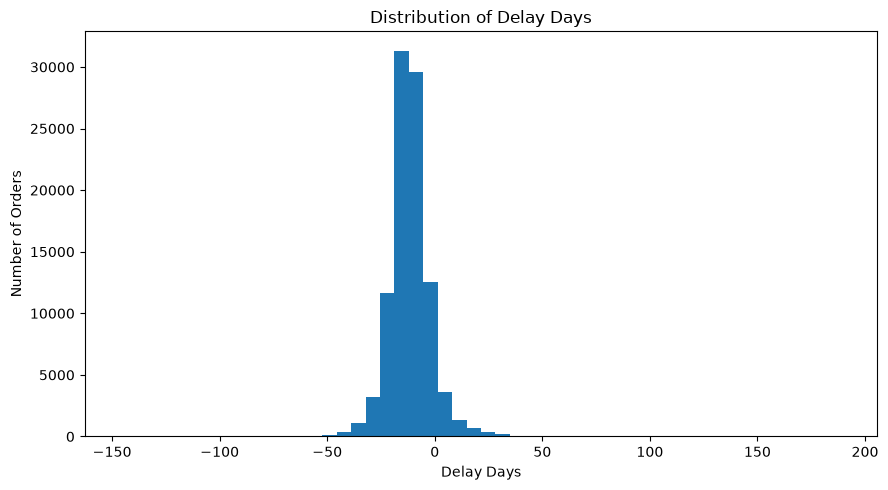

In [11]:
import matplotlib.pyplot as plt

# 1. Classification: 0 vs 1
ml_table["delayed"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)
plt.title("Order Delay Classification")
plt.xlabel("Delayed (0 = On Time, 1 = Late)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Delay periods among late orders
late = ml_table[ml_table["delayed"] == 1].copy()

late["delay_period"] = pd.cut(
    late["delay_days"],
    bins=[0, 7, 14, 21, 30, 60, 90, 180, 365, float("inf")],
    labels=[
        "≤ 1 week", "1–2 weeks", "2–3 weeks", "3–4 weeks",
        "1–2 months", "2–3 months", "3–6 months",
        "6–12 months", "> 1 year"
    ]
)

late["delay_period"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Delay Duration Among Late Orders")
plt.xlabel("Delay Period")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Numeric distribution of delay_days
ml_table["delay_days"].dropna().plot(
    kind="hist",
    bins=50,
    figsize=(9, 5)
)
plt.title("Distribution of Delay Days")
plt.xlabel("Delay Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# 13. SAVE LABELED TABLE
# ============================================================

output_path = "../data/ML_Table_Labeled_2.csv"
ml_table.to_csv(output_path,index=False)
print("\n" + "=" * 100)
print("SAVED")
print("=" * 100)
print(f"File: {output_path}")
print(f"Shape: {ml_table.shape}")


SAVED
File: ../data/ML_Table_Labeled_2.csv
Shape: (99441, 82)
